![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning

### Portfolio uchun vazifa: Toshkent shahrida uylarning narxini aniqlash.

Ushbu amaliyotda sizning vazifangiz berilgan ma`lumotlar asosida Toshkent shahridagi uylarning narxini aniqlash.

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


# Ustunlar ta'rifi
- `location` - sotilayotgan uy manzili
- `district` - uy joylashgan tuman
- `rooms` - xonalar soni
- `size` - uy maydoni (kv.m)
- `level` - uy joylashgan qavat
- `max_levels` - ja'mi qavatlar soni
- `price` - uy narxi

## Vazifani CRSIP-DM Metolodgiyasi yordamida bajaring.
<img src="https://i.imgur.com/dzZnnYi.png" alt="CRISP-DM" width="800"/>

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Bizga tayyor data havolasi berilgan lekin men o'zimni GITHUB akauntimda shu data bo'lgani uchun uni GITHUB dan chaqirib oldim.

In [3]:
!git clone https://github.com/dilshod12352005/data1.git

Cloning into 'data1'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 24 (delta 5), reused 22 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 21.73 MiB | 20.45 MiB/s, done.
Resolving deltas: 100% (5/5), done.


# Malumotlarimizni chaqirib oldik
`Bizga qo'yilgan masala uylarni narhini bashorat qilish .`

In [4]:
df=pd.read_excel('/content/data1/uybor.xlsx')

# 1- bizga berilgan datani tushuni olamiz.

In [5]:
df.head()

,address,district,rooms,size,level,max_levels,price,lat,lng
0,"город Ташкент, Yunusobod район, Юнусабад 8-й к...",Yunusobod,3,57.0,4,4,52000,41.371471,69.281049
1,"город Ташкент, Yakkasaroy район, 1-й тупик Шот...",Yakkasaroy,2,52.0,4,5,56000,41.291115,69.261104
2,"город Ташкент, Chilonzor район, Чиланзар 2-й к...",Chilonzor,2,42.0,4,4,37000,41.280784,69.223683
3,"город Ташкент, Chilonzor район, Чиланзар 9-й к...",Chilonzor,3,65.0,1,4,49500,41.290163,69.196862
4,"город Ташкент, Chilonzor район, площадь Актепа",Chilonzor,3,70.0,3,5,55000,41.300156,69.210831


In [6]:
#bizga lat va lng ustunlarini ishlatmaymiz .
df=df.drop(["lat","lng"], axis=1)

In [7]:
df.head()

,address,district,rooms,size,level,max_levels,price
0,"город Ташкент, Yunusobod район, Юнусабад 8-й к...",Yunusobod,3,57.0,4,4,52000
1,"город Ташкент, Yakkasaroy район, 1-й тупик Шот...",Yakkasaroy,2,52.0,4,5,56000
2,"город Ташкент, Chilonzor район, Чиланзар 2-й к...",Chilonzor,2,42.0,4,4,37000
3,"город Ташкент, Chilonzor район, Чиланзар 9-й к...",Chilonzor,3,65.0,1,4,49500
4,"город Ташкент, Chilonzor район, площадь Актепа",Chilonzor,3,70.0,3,5,55000


# df ni bizga kerak bo'lmagan ustunlardan tozalab uni df ga saqlab oldim endi uni ustida ishlasak bo'ladi

In [8]:
df.to_csv("Toshkent_uy.csv")

In [13]:
# df ustun va qatorlari soni type haqida malumot
df.info()
# ko'rib turibmiz df da NAN qiymatlar yo'w bu judayam yaxshi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7421 entries, 0 to 7420
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   address     7421 non-null   object 
 1   district    7421 non-null   object 
 2   rooms       7421 non-null   int64  
 3   size        7421 non-null   float64
 4   level       7421 non-null   int64  
 5   max_levels  7421 non-null   int64  
 6   price       7421 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 406.0+ KB


In [12]:
df.describe()

,rooms,size,level,max_levels,price
count,7421.000000,7421.000000,7421.000000,7421.000000,7421.000000
mean,2.619728,73.150726,3.699367,6.031397,59117.618919
std,1.076887,36.999670,2.239028,2.607673,46701.090308
min,1.000000,14.000000,1.000000,1.000000,10500.000000
25%,2.000000,50.000000,2.000000,4.000000,35000.000000
50%,3.000000,65.000000,3.000000,5.000000,46500.000000
75%,3.000000,85.000000,5.000000,9.000000,66847.000000
max,10.000000,456.000000,19.000000,25.000000,800000.000000


# Uylarni narxini hududlarga bog'liqlik `scatterplot` grafigini chizib olamiz

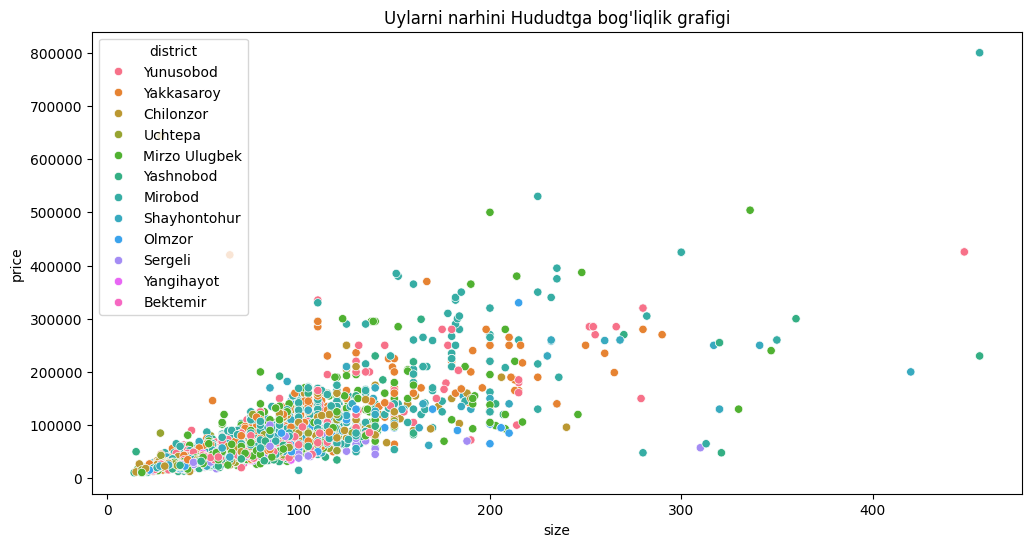

In [14]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='size', y='price', hue='district')
plt.title("Uylarni narhini Hududtga bog'liqlik grafigi")
plt.show()

# Bu grafikda necha honali uylar ko'proq ekanligini yoki nechi honali uylar sanoqli ekanligini ko'rsak bo'ladi .
# Bu  nimaga kerak ? Masalan 10 xonali uylar sanoqli ularni balkim tashlab yuborarmiz chunki 10 xonali uylarni narxi juda qimmat bo'ladi bu esa modelimizni adshtirishi mumkin.

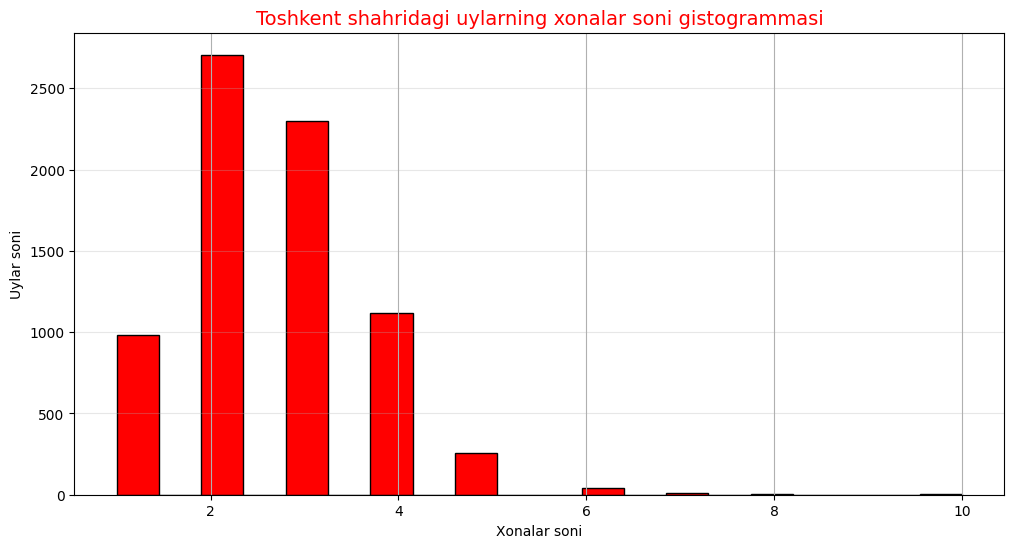

In [15]:
plt.figure(figsize=(12, 6))
df["rooms"].hist(bins=20, color='red', edgecolor='black')
plt.title("Toshkent shahridagi uylarning xonalar soni gistogrammasi", color='red', fontsize=14)
plt.xlabel("Xonalar soni")
plt.ylabel("Uylar soni")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Grafigimizda asosan uylar qaysi nar oralig'ida ekanligini ko'rsak bo'ladi . Bizda uylarni narxi asosan 100 000dan kam ekan. Bu grafikda ko'rinib turibdiki narxi 300 000$ dan oshgan uylar sanoqli ekan bularni tshlab yuborsak ham bo'ladi.

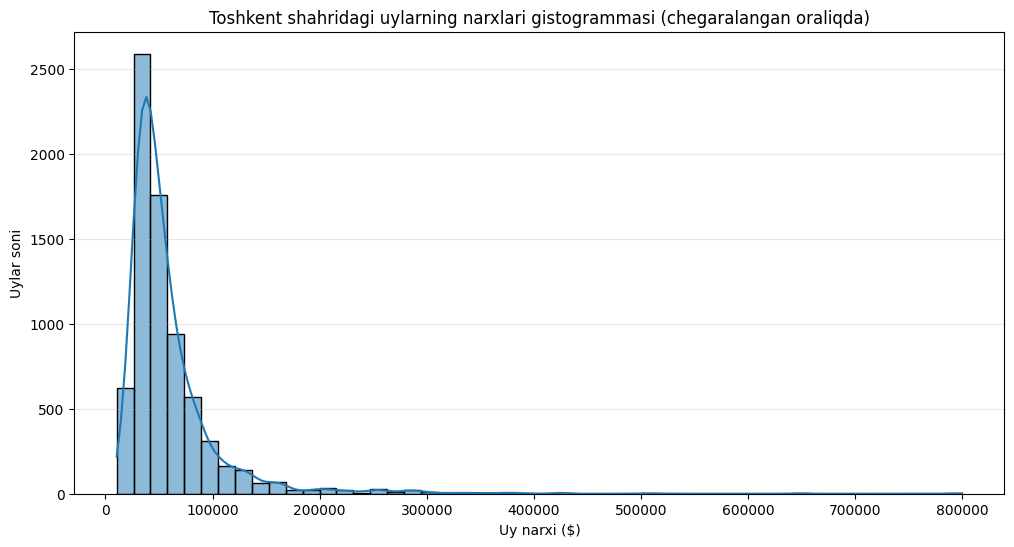

In [16]:
# Grafikni chizish
plt.figure(figsize=(12, 6))
# Seaborn orqali chiroyli gistogramma chizamiz
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Toshkent shahridagi uylarning narxlari gistogrammasi (chegaralangan oraliqda)")
plt.xlabel("Uy narxi ($)")
plt.ylabel("Uylar soni")
plt.grid(axis='y', alpha=0.3)

plt.show()


# BU grafikda qaysi tumadan uylarni o'rtacha narxini ko'rsak bo'ladi . qaysi tumanda uylar qimmatroq.
<img src="https://xabar.uz/static/crop/2/3/920__95_2301895770.jpg" alt="CRISP-DM" width="800"/>

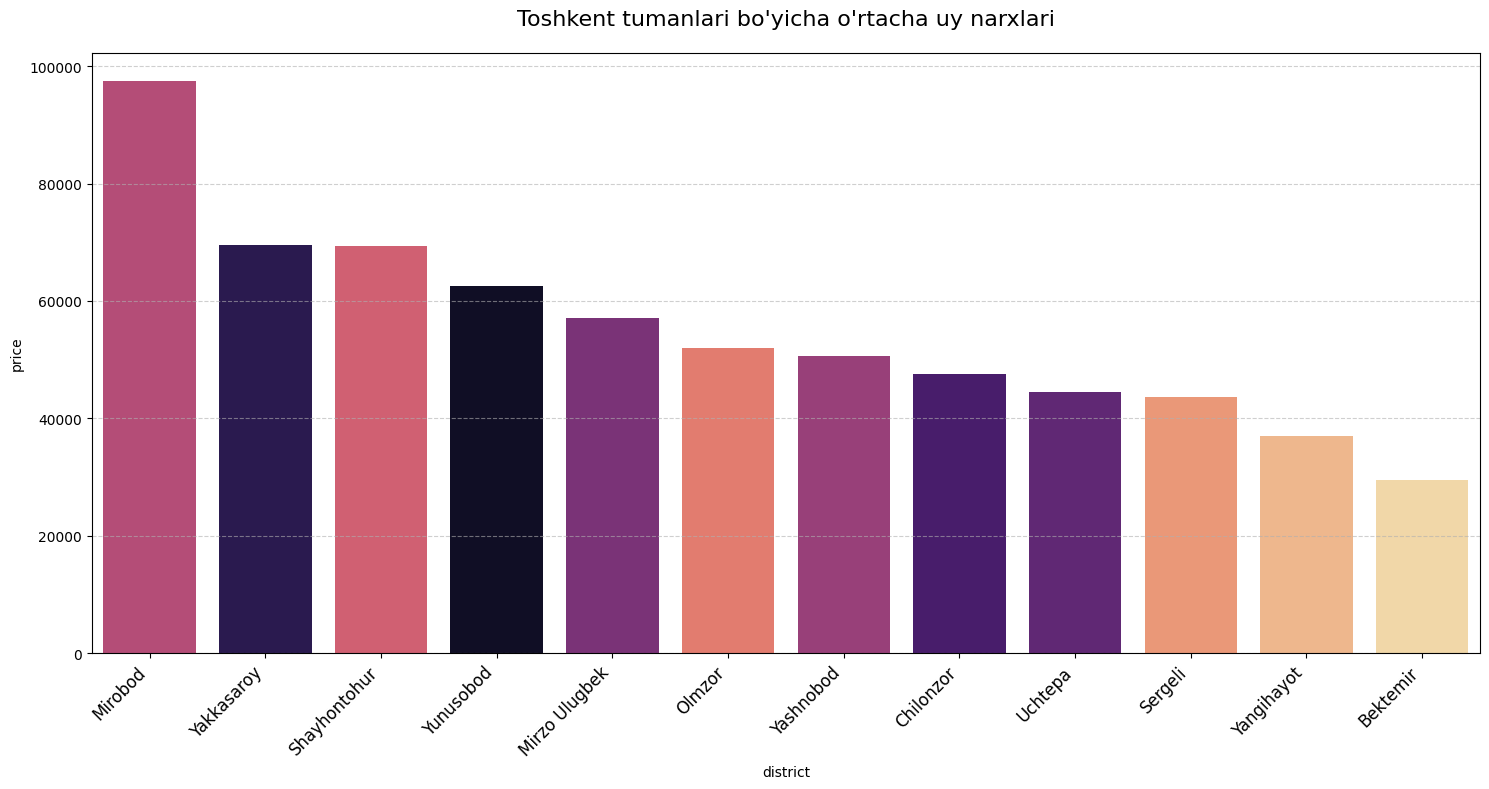

In [22]:
plt.figure(figsize=(15, 8))
# Narxlar bo'yicha tumanlarni tartiblash
order = df.groupby('district')['price'].mean().sort_values(ascending=False).index
sns.barplot(
    data=df,
    x='district',
    y='price',
    hue='district',
    palette='magma',
    order=order,
    errorbar=None,
    legend=False
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title("Toshkent tumanlari bo'yicha o'rtacha uy narxlari", fontsize=16, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [30]:
df.head()

,address,district,rooms,size,level,max_levels,price
0,"город Ташкент, Yunusobod район, Юнусабад 8-й к...",Yunusobod,3,57.0,4,4,52000
1,"город Ташкент, Yakkasaroy район, 1-й тупик Шот...",Yakkasaroy,2,52.0,4,5,56000
2,"город Ташкент, Chilonzor район, Чиланзар 2-й к...",Chilonzor,2,42.0,4,4,37000
3,"город Ташкент, Chilonzor район, Чиланзар 9-й к...",Chilonzor,3,65.0,1,4,49500
4,"город Ташкент, Chilonzor район, площадь Актепа",Chilonzor,3,70.0,3,5,55000


In [31]:
# Faqat maydoni 20 dan katta va 500 dan kichik uylarni qoldiramiz
# Narxi esa 10 000 dan baland uylarni olamiz
df = df[(df['size'] > 20) & (df['size'] < 500)]
df = df[(df['price'] > 10000) & (df['price'] < 1000000)]

In [32]:
# Bashorat qilmoqchi bo'lgan qiymatimiz (Label) - Narx
y = df['price'].copy()
# Bashorat qilish uchun foydalanadigan xususiyatlarimiz (Features)
X = df[['rooms', 'size', 'district']].copy()

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"O'qitish uchun: {len(X_train)} ta, Tekshirish uchun: {len(X_test)} ta ma'lumot.")

O'qitish uchun: 5902 ta, Tekshirish uchun: 1476 ta ma'lumot.


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Sonli va matnli ustunlarni ajratib olamiz
num_cols = ['rooms', 'size']
cat_cols = ['district']

# 2. Transformerlarni tayyorlaymiz
# Sonlar uchun StandardScaler, matnlar uchun OneHotEncoder
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Ustunlarni qayta ishlashni birlashtiramiz
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# 4. To'liq Pipeline quramiz (Tayyorlov + Model)
# Biz RandomForestRegressor modelidan foydalanamiz (u odatda juda aniq ishlaydi)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 5. Modelni o'qitish (Fit)
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['rooms', 'size']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['district'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [35]:
# Bashorat qilish
y_pred = model.predict(X_test)
# Xatolikni hisoblash (O'rtacha necha dollarga adashayotganimizni ko'ramiz)
mae = mean_absolute_error(y_test, y_pred)
print(f"Model o'rtacha {mae:.2f} $ ga adashmoqda.")

Model o'rtacha 12560.81 $ ga adashmoqda.


In [38]:
from sklearn.metrics import mean_squared_error
# Endi hisoblasangiz bo'ladi:
mse = mean_squared_error(y_test, y_pred)
# RMSE ni hisoblash
rmse = np.sqrt(mse)
print(f"RMSE (O'rtacha xatolik): {rmse:.2f} $")

RMSE (O'rtacha xatolik): 27985.60 $


In [40]:
df1 = df[(df['size'] > 20) & (df['size'] < 500)]
df1 = df[(df['price'] > 10000) & (df['price'] < 300000)]

In [43]:
df.shape

(7378, 7)

In [44]:
# Bashorat qilmoqchi bo'lgan qiymatimiz (Label) - Narx
y = df1['price'].copy()
# Bashorat qilish uchun foydalanadigan xususiyatlarimiz (Features)
X = df1[['rooms', 'size', 'district']].copy()

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"O'qitish uchun: {len(X_train)} ta, Tekshirish uchun: {len(X_test)} ta ma'lumot.")

O'qitish uchun: 5869 ta, Tekshirish uchun: 1468 ta ma'lumot.


# Bu bosqichda rooms va size ustunlari o'rtacha qiymati $0$, standart og'ishi $1$ bo'lgan holatga keladi.
# Nima o'zgardi? Endi bizda $70$ yoki $3$ degan sonlar yo'q. Ularning o'rniga $-1.2$ yoki $0.5$ kabi kichik sonlar paydo bo'ldi. Bu modelga "kattaroq son muhimroq" deb o'ylamaslikka yordam beradi.

In [46]:
# Faqat sonli ustunlarni olamiz va scaler-ni ishlatamiz
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_train[['rooms', 'size']])

# Natijani ko'ramiz (birinchi 5 ta qator)
print("StandardScaler natijasi (Raqamlar qanday o'zgardi):")
print(X_num_scaled[:5])

StandardScaler natijasi (Raqamlar qanday o'zgardi):
[[-1.5384507  -1.2530079 ]
 [-1.5384507  -1.36968881]
 [-1.5384507  -0.96130563]
 [ 0.35069401 -0.02785839]
 [ 0.35069401 -0.02785839]]


Bu qismda "Chilonzor" kabi so'zlar $0$ va $1$ lardan iborat ustunlarga aylanadi.
Nima o'zgardi? Agar sizda $11$ ta tuman bo'lsa, har bir qator uchun $11$ ta katakcha hosil bo'ldi. Uy qaysi tumanda bo'lsa, o'sha tumanning katagida $1$ raqami, qolganlarida $0$ turadi.

In [47]:
# Faqat tumanlarni olamiz va encoder-ni ishlatamiz
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_train[['district']])

# Natijani va yangi ustun nomlarini ko'ramiz
print("OneHotEncoder natijasi (Tumanlar raqamga aylandi):")
print(X_cat_encoded[:5])
print("\nYangi ustunlar (Tumanlar):", encoder.get_feature_names_out())

OneHotEncoder natijasi (Tumanlar raqamga aylandi):
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Yangi ustunlar (Tumanlar): ['district_Bektemir' 'district_Chilonzor' 'district_Mirobod'
 'district_Mirzo Ulugbek' 'district_Olmzor' 'district_Sergeli'
 'district_Shayhontohur' 'district_Uchtepa' 'district_Yakkasaroy'
 'district_Yangihayot' 'district_Yashnobod' 'district_Yunusobod']


In [48]:
# Pipeline-dagi preprocessor-ni alohida ishlatib ko'ramiz
X_processed = preprocessor.fit_transform(X_train)

print("Birlashtirilgan ma'lumotlar shakli (Shape):", X_processed.shape)
print("\nTayyor ma'lumot (birinchi qator):")
print(X_processed[0])

Birlashtirilgan ma'lumotlar shakli (Shape): (5869, 14)

Tayyor ma'lumot (birinchi qator):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (1, 14)>
  Coords	Values
  (0, 0)	-1.5384507036426287
  (0, 1)	-1.2530078993351286
  (0, 3)	1.0


In [50]:
# 1. Ma'lumotlarni to'g'ri filtrlash
df1 = df[(df['size'] > 20) & (df['size'] < 500) & (df['price'] > 10000) & (df['price'] < 300000)]

# 2. X va y ni qayta belgilash
y = df1['price'].copy()
X = df1[['rooms', 'size', 'district']].copy()

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Pipeline-ni o'qitish (Fit)
# Avval yaratgan 'model' nomli pipeline-ni ishlating
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['rooms', 'size']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['district'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [51]:
# Yangi uy ma'lumotlarini kiritamiz
yangi_uy = pd.DataFrame({
    'rooms': [2],
    'size': [60],
    'district': ['Чиланзарский'] # Diqqat: Tuman nomi datasetdagidek bo'lishi shart
})

# Model orqali narxni topamiz
bashorat_narx = model.predict(yangi_uy)

print(f"Bashorat qilingan narx: {bashorat_narx[0]:.2f} $")

Bashorat qilingan narx: 41282.21 $


In [57]:
df.sample(20)

,address,district,rooms,size,level,max_levels,price
5657,"город Ташкент, Chilonzor район, Аль-Хорезми-2",Chilonzor,2,60.0,4,4,33500
3012,"город Ташкент, Mirobod район, ОЙБЕК, ( Шох Мед...",Mirobod,5,200.0,8,9,125000
4840,"город Ташкент, Mirzo Ulugbek район, Феруза-1",Mirzo Ulugbek,2,45.0,1,4,35500
6892,"город Ташкент, Chilonzor район, Чиланзар-3",Chilonzor,2,45.0,2,5,37000
3154,"город Ташкент, Mirobod район, Тараса Шевченко",Mirobod,2,60.0,5,16,69000
4181,"город Ташкент, Mirzo Ulugbek район, Карасу 3-й...",Mirzo Ulugbek,4,93.0,3,5,62000
2689,"город Ташкент, Chilonzor район, 1-й проезд Кат...",Chilonzor,1,42.0,6,9,22000
5016,"город Ташкент, Yakkasaroy район, Шота Руставели",Yakkasaroy,3,70.0,3,4,68000
3274,"город Ташкент, Mirzo Ulugbek район, Ялангач",Mirzo Ulugbek,2,50.0,1,4,31000
166,"город Ташкент, Mirzo Ulugbek район, жилой комп...",Mirzo Ulugbek,3,107.0,2,8,85000


In [58]:
# Bashorat qilish
y_pred = model.predict(X_test)
# Xatolikni hisoblash (O'rtacha necha dollarga adashayotganimizni ko'ramiz)
mae = mean_absolute_error(y_test, y_pred)
print(f"Model o'rtacha {mae:.2f} $ ga adashmoqda.")

Model o'rtacha 11199.98 $ ga adashmoqda.


In [59]:
from sklearn.metrics import mean_squared_error
# Endi hisoblasangiz bo'ladi:
mse = mean_squared_error(y_test, y_pred)
# RMSE ni hisoblash
rmse = np.sqrt(mse)
print(f"RMSE (O'rtacha xatolik): {rmse:.2f} $")

RMSE (O'rtacha xatolik): 18525.92 $


Madelimoz endi ancha aniq ishlamoqda